In [75]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
import heapq
import math

# 目標色の生成における各絵の具のグラム数

平均値: 0.9956232238846083
中央値: 0.6921466802263617
標準偏差: 0.9849589089219601


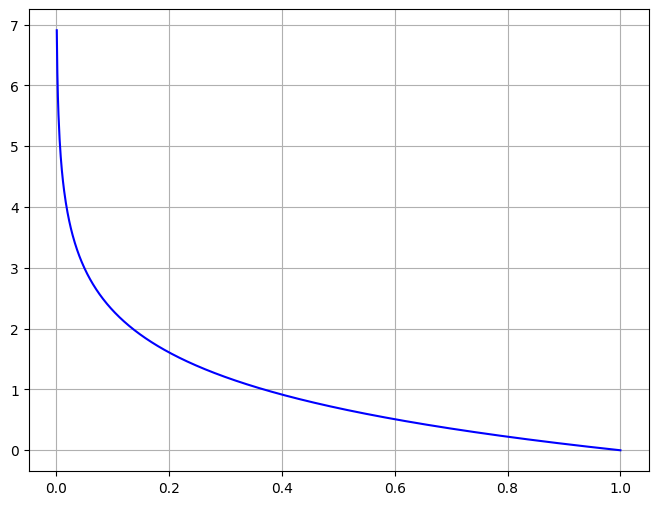

In [2]:
# 0から1までの等間隔な値を生成
samples = np.linspace(0, 1, 1000)[1:]

# 対応する -ln(rand_double(0,1)) を計算
values = -np.log(samples)
print(f'平均値: {np.mean(values)}')
print(f'中央値: {np.median(values)}')
print(f'標準偏差: {np.std(values)}')

# グラフをプロット
plt.figure(figsize=(8, 6))
plt.plot(samples, values, color="blue")
plt.grid()
plt.show()

In [3]:
n = len(values)
cnt = [0 for _ in range(n)]
for v in values[1:]:
    cnt[int(v)] += 1
for i in range(100):
    if cnt[i] == 0:
        continue
    print(f'{i+1}未満: {cnt[i]}回')

1未満: 632回
2未満: 232回
3未満: 86回
4未満: 31回
5未満: 12回
6未満: 4回
7未満: 1回


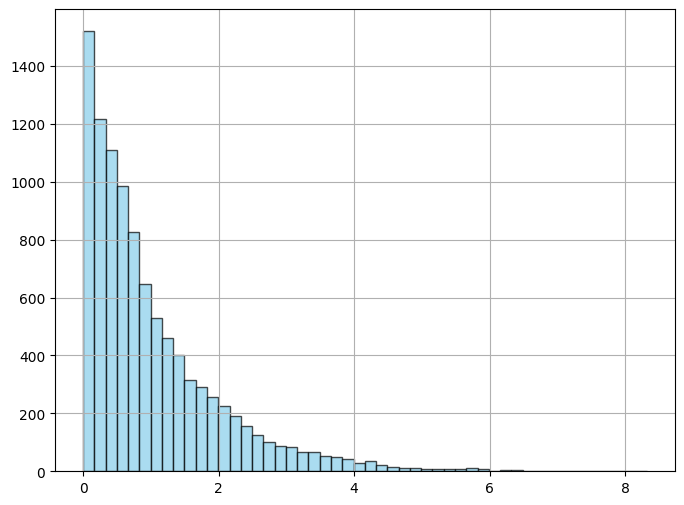

In [4]:
# サンプル数
num_samples = 10000

# モンテカルロでランダム値を生成 (1から4の範囲でランダムサンプリング)
random_samples = np.random.uniform(0, 1, num_samples)

# 対応する値を計算：10^samples
values = -np.log(random_samples)

# ヒストグラムをプロット
plt.figure(figsize=(8, 6))
plt.hist(values, bins=50, color='skyblue', alpha=0.7, edgecolor='black')
plt.grid()
plt.show()

# 絵具と目標の色との誤差

In [5]:
def load_input(filename):
    with open(filename, "r") as file:
        n, k, h, t, d = map(int, file.readline().split())
        own = []
        for _ in range(k):
            (c, m, y) = map(float, file.readline().split())
            own.append((c,m,y))
        target = []
        for _ in range(h):
            (c, m, y) = map(float, file.readline().split())
            target.append((c,m,y))
        assert n==20
        assert h==1000
        assert len(own)==k
        assert len(target)==h
        print(f'K={k}, T={t}, D={d}')
    return n, k, h, t, d, own, target

n, k, h, t, d, own, target = load_input('in/0000.txt')

K=4, T=60887, D=3822


In [6]:
def dist(cmy1, cmy2):
    c1, m1, y1 = cmy1
    c2, m2, y2 = cmy2
    e = ((c1-c2)**2 + (m1-m2)**2 + (y1-y2)**2)**(1/2)
    return e

score = 1
for i, (c2,m2,y2) in enumerate(target):
    # print(f'i: {i}', end='')
    errors = []
    for j, (c1,m1,y1) in enumerate(own):
        e = dist((c1,m1,y1), (c2,m2,y2))
        errors.append(e)
        # print(f', k{j} e: {e}', end='')
    score += min(errors)
    # print('')
score *= 10000
score = round(score)
print(f'score: {score:,}')

score: 2,319,645


In [7]:
print(f'目標の色: {target[0]}')
print(f'絵の具: {own}')
def mixing_color(cnt):
    (c1, m1, y1) = (0, 0, 0)
    s = 0
    for i, c in enumerate(cnt):
        (c2, m2, y2) = own[i]
        s += c
        c1 += c2*c
        m1 += m2*c
        y1 += y2*c
    if s != 0:
        c1 /= s
        m1 /= s
        y1 /= s
    color = (c1, m1, y1)
    return color

mixing_color([0, 0, 0, 0])
mixing_color([1, 1, 1, 1])

k2 = 30

cnt = 0
opt_trial = [0, 0, 0, 0]
opt_score = 1_000_000_000
for c1 in range(k2):
    for c2 in range(k2):
        for c3 in range(k2):
            for c4 in range(k2):
                trial = [c1, c2, c3, c4]
                cnt += 1
                color = mixing_color(trial)
                # score = 10000*dist(color, target[0]) + d*(sum(trial)-1)
                score = 10000*dist(color, target[0])
                if score < opt_score:
                    print(f'trial cnt: {cnt}, trial: {trial}, color: {color}, e: {dist(color, target[0])}, score: {round(score)}')
                    opt_score = score
                    opt_trial = trial
print(f'opt score: {opt_score}, trial: {opt_trial}, cnt: {cnt}')

目標の色: (0.44983, 0.33494, 0.51708)
絵の具: [(0.18582, 0.09589, 0.89627), (0.5242, 0.23682, 0.12026), (0.25071, 0.05604, 0.4965), (0.65334, 0.67404, 0.51617)]
trial cnt: 1, trial: [0, 0, 0, 0], color: (0.0, 0.0, 0.0), e: 0.7628260344927931, score: 7628
trial cnt: 2, trial: [0, 0, 0, 1], color: (0.65334, 0.67404, 0.51617), e: 0.395481931572101, score: 3955
trial cnt: 31, trial: [0, 0, 1, 0], color: (0.25071, 0.05604, 0.4965), e: 0.34330383161275674, score: 3433
trial cnt: 32, trial: [0, 0, 1, 1], color: (0.452025, 0.36504, 0.506335), e: 0.032035652794972, score: 320
trial cnt: 155, trial: [0, 0, 5, 4], color: (0.42965666666666663, 0.33070666666666665, 0.5052422222222223), e: 0.02377009616314034, score: 238
trial cnt: 186, trial: [0, 0, 6, 5], color: (0.4337236363636364, 0.33694909090909086, 0.5054409090909091), e: 0.0199729775711547, score: 200
trial cnt: 217, trial: [0, 0, 7, 6], color: (0.4365392307692308, 0.34127076923076927, 0.5055784615384615), e: 0.018681771136085164, score: 187
trial 

# Dの分布

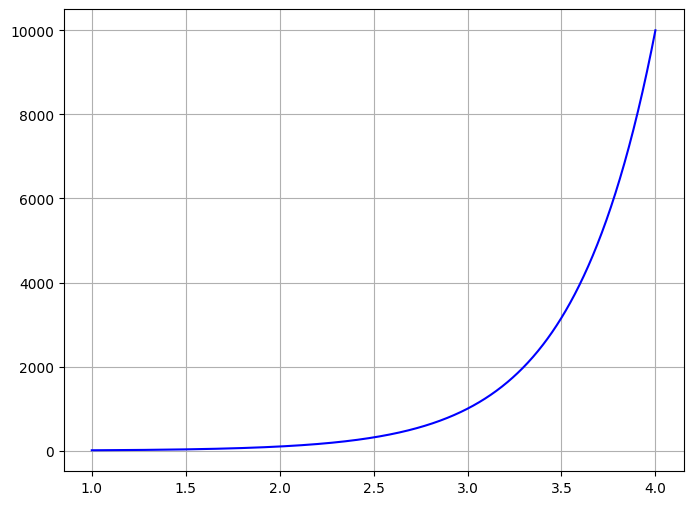

In [8]:
# 0から1までの等間隔な値を生成
samples = np.linspace(1, 4, 1000)

# 対応する -ln(rand_double(0,1)) を計算
values = 10**samples

# グラフをプロット
plt.figure(figsize=(8, 6))
plt.plot(samples, values, color="blue")
plt.grid()
plt.show()

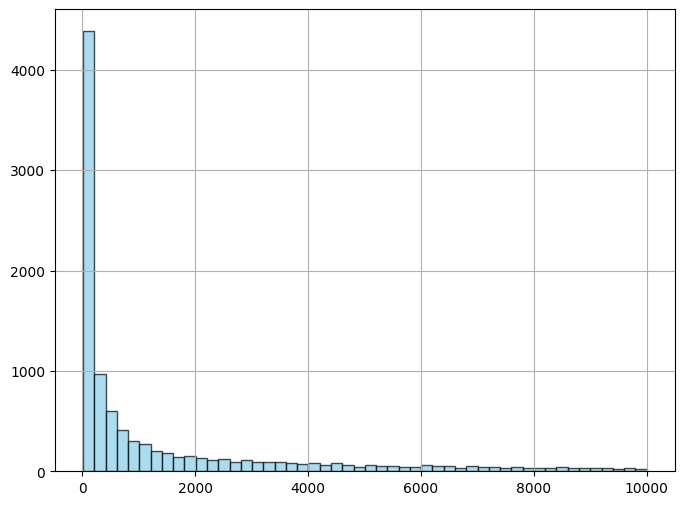

In [9]:
# サンプル数
num_samples = 10000

# モンテカルロでランダム値を生成 (1から4の範囲でランダムサンプリング)
random_samples = np.random.uniform(1, 4, num_samples)

# 対応する値を計算：10^samples
values = 10 ** random_samples

# ヒストグラムをプロット
plt.figure(figsize=(8, 6))
plt.hist(values, bins=50, color='skyblue', alpha=0.7, edgecolor='black')
plt.grid()
plt.show()

# seed=1

In [10]:
n, k, h, t, d, own, target = load_input('in/0001.txt')

score = 1
for i, (c2,m2,y2) in enumerate(target):
    # print(f'i: {i}', end='')
    errors = []
    for j, (c1,m1,y1) in enumerate(own):
        e = dist((c1,m1,y1), (c2,m2,y2))
        errors.append(e)
        # print(f', k{j} e: {e}', end='')
    score += min(errors)
    # print('')
score *= 10000
score = round(score)
print(f'score: {score:,}')

cnt = 0
opt_trial = [0, 0, 0, 0]
opt_score = 1_000_000_000
for c1 in range(k):
    for c2 in range(k):
        for c3 in range(k):
            for c4 in range(k):
                trial = [c1, c2, c3, c4]
                cnt += 1
                color = mixing_color(trial)
                score = 10000*dist(color, target[0]) + d*(sum(trial)-1)
                if score < opt_score:
                    print(f'trial cnt: {cnt}, trial: {trial}, color: {color}, e: {dist(color, target[0])}, score: {round(score)}')
                    opt_score = score
                    opt_trial = trial
print(f'opt score: {opt_score}, trial: {opt_trial}, cnt: {cnt}')

K=9, T=23052, D=13
score: 2,220,598
trial cnt: 1, trial: [0, 0, 0, 0], color: (0.0, 0.0, 0.0), e: 0.8746329514716445, score: 8733
trial cnt: 2, trial: [0, 0, 0, 1], color: (0.07822, 0.81449, 0.27609), e: 0.7284754476301861, score: 7285
trial cnt: 10, trial: [0, 0, 1, 0], color: (0.29789, 0.20344, 0.44055), e: 0.34489363432803455, score: 3449
trial cnt: 83, trial: [0, 1, 0, 1], color: (0.50061, 0.49819500000000005, 0.265635), e: 0.3140574591535759, score: 3154
trial cnt: 91, trial: [0, 1, 1, 0], color: (0.610445, 0.19267, 0.347865), e: 0.25482871551298925, score: 2561
trial cnt: 100, trial: [0, 1, 2, 0], color: (0.50626, 0.19626000000000002, 0.37876), e: 0.2435128657792027, score: 2461
trial cnt: 173, trial: [0, 2, 1, 1], color: (0.5555275, 0.34543250000000003, 0.30675), e: 0.23182347705204492, score: 2357
trial cnt: 182, trial: [0, 2, 2, 1], color: (0.504, 0.31703400000000004, 0.33351), e: 0.2237708666828638, score: 2290
trial cnt: 272, trial: [0, 3, 3, 1], color: (0.5344128571428571, 

# 3つの絵の具で目標の色を作成

In [11]:
(c, m, y) = target[0]
(c1, m1, y1) = own[0]
(c2, m2, y2) = own[1]
(c3, m3, y3) = own[2]

def coefficient(cmy, cmy1, cmy2, cmy3):
    (c, m, y) = cmy
    (c1, m1, y1) = cmy1
    (c2, m2, y2) = cmy2
    (c3, m3, y3) = cmy3
    
    # 行列の決定因子(デターミナント)を計算
    det = (
        c1 * (m2 * y3 - y2 * m3)
        - m1 * (c2 * y3 - y2 * c3)
        + y1 * (c2 * m3 - m2 * c3)
    )

    if det == 0:
        (0, 0, 0)

    # 係数を計算
    a1 = (
        c * (m2 * y3 - y2 * m3)
        - m * (c2 * y3 - y2 * c3)
        + y * (c2 * m3 - m2 * c3)
    ) / det

    a2 = (
        c1 * (m * y3 - y * m3)
        - m1 * (c * y3 - y * c3)
        + y1 * (c * m3 - m * c3)
    ) / det

    a3 = (
        c1 * (m2 * y - y2 * m)
        - m1 * (c2 * y - y2 * c)
        + y1 * (c2 * m - m2 * c)
    ) / det
    
    return (a1, a2, a3)

coefficient((c, m, y), (c1, m1, y1), (c2, m2, y2), (c3, m3, y3))

(0.8911469030880155, 0.2824435123558617, -0.5361482317658894)

# 2つの絵の具で目標の色を作成

In [12]:
(c, m, y) = target[0]
print(f'target: {target[0]}')

primes = [2, 3, 5]
opt_i1 = 0
opt_i2 = 0
opt_p = 0
opt_i = 0
opt_e = dist((c,m,y), own[0])


for i1 in range(k):
    (c1, m1, y1) = own[i1]
    e = dist((c,m,y), (c1,m1,y1))  # 1つだけ
    if opt_e > e:
        print(f'update {opt_e} => {e}, i1: {i1}, cmy: {(cc,mm,yy)}')
        opt_i1 = i1
        opt_e = e
    for i2 in range(k):
        (c2, m2, y2) = own[i2]
        cc = (c1 + c2) / 2
        mm = (m1 + m2) / 2
        yy = (y1 + y2) / 2
        e = dist((c,m,y), (cc,mm,yy))
        if opt_e > e:
            print(f'update {opt_e} => {e}, i1: {i1}, i2: {i2}, cmy: {(cc,mm,yy)}')
            opt_i1 = i1
            opt_i2 = i2
            opt_p = 1
            opt_i = 1
            opt_e = e
        for p in primes:
            for i in range(1, p):
                cc = (c1*i + c2*p) / (i+p)
                mm = (m1*i + m2*p) / (i+p)
                yy = (y1*i + y2*p) / (i+p)
                e = dist((c,m,y), (cc,mm,yy))
                if opt_e > e:
                    print(f'update {opt_e} => {e}, i1: {i1}, i2: {i2}, p: {p}, i: {i}, cmy: {(cc,mm,yy)}')
                    opt_i1 = i1
                    opt_i2 = i2
                    opt_p = 1
                    opt_i = 1
                    opt_e = e


target: (0.58819, 0.36361, 0.53554)
update 0.27555550185035316 => 0.15187054602522512, i1: 0, i2: 1, cmy: (0.7348600000000001, 0.32733500000000004, 0.520155)
update 0.15187054602522512 => 0.1505725642339932, i1: 0, i2: 5, cmy: (0.71638, 0.43834, 0.50995)
update 0.1505725642339932 => 0.1118833625800648, i1: 1, i2: 0, p: 2, i: 1, cmy: (0.6721466666666668, 0.37581333333333333, 0.60848)
update 0.1118833625800648 => 0.1118648858696285, i1: 1, i2: 0, p: 5, i: 3, cmy: (0.687825, 0.36369375000000004, 0.5863987500000001)
update 0.1118648858696285 => 0.10030912894647226, i1: 7, i2: 8, cmy: (0.540805, 0.32914000000000004, 0.616955)
update 0.10030912894647226 => 0.07296245625129566, i1: 7, i2: 8, p: 2, i: 1, cmy: (0.63882, 0.41597333333333336, 0.5398066666666667)
update 0.07296245625129566 => 0.040928725267225255, i1: 7, i2: 8, p: 3, i: 2, cmy: (0.5996140000000001, 0.38124, 0.570666)


## seed=0

In [13]:
n, k, h, t, d, own, target = load_input('in/0000.txt')

score = 1
for i, (c2,m2,y2) in enumerate(target):
    # print(f'i: {i}', end='')
    errors = []
    for j, (c1,m1,y1) in enumerate(own):
        e = dist((c1,m1,y1), (c2,m2,y2))
        errors.append(e)
        # print(f', k{j} e: {e}', end='')
    score += min(errors)
    # print('')
score *= 10000
score = round(score)
print(f'1つのみscore: {score:,}')


primes = [2, 3, 5]
score = 1

for (c,m,y) in tqdm(target):
    # print(f'target: {(c,m,y)}')
    opt_i1 = 0
    opt_i2 = 0
    opt_p = 0
    opt_i = 0
    opt_e = dist((c,m,y), own[0])
    opt_s = opt_e*10000
    for i1 in range(k):
        (c1, m1, y1) = own[i1]
        e = dist((c,m,y), (c1,m1,y1))  # 1つだけ
        s = e*10000
        if opt_s > s:
            # print(f'update {opt_e} => {e}, i1: {i1}, cmy: {(cc,mm,yy)}')
            opt_i1 = i1
            opt_e = e
            opt_s = s
        for i2 in range(k):
            (c2, m2, y2) = own[i2]
            cc = (c1 + c2) / 2
            mm = (m1 + m2) / 2
            yy = (y1 + y2) / 2
            e = dist((c,m,y), (cc,mm,yy))
            s = e*10000+d
            if opt_s > s:
                # print(f'update {opt_e} => {e}, i1: {i1}, i2: {i2}, cmy: {(cc,mm,yy)}')
                opt_i1 = i1
                opt_i2 = i2
                opt_p = 1
                opt_i = 1
                opt_e = e
                opt_s = s
            for p in primes:
                for i in range(1, p):
                    cc = (c1*i + c2*p) / (i+p)
                    mm = (m1*i + m2*p) / (i+p)
                    yy = (y1*i + y2*p) / (i+p)
                    e = dist((c,m,y), (cc,mm,yy))
                    s = e*10000+d
                    if opt_s > s:
                        # print(f'update {opt_e} => {e}, i1: {i1}, i2: {i2}, p: {p}, i: {i}, cmy: {(cc,mm,yy)}')
                        opt_i1 = i1
                        opt_i2 = i2
                        opt_p = 1
                        opt_i = 1
                        opt_e = e
                        opt_s = s
    score += opt_s

print(f'2つ使うscore: {round(score):,}')

K=4, T=60887, D=3822
1つのみscore: 2,319,645


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 6693.69it/s]

2つ使うscore: 2,309,565


# seed=1

In [14]:
n, k, h, t, d, own, target = load_input('in/0001.txt')

score = 1
for i, (c2,m2,y2) in enumerate(target):
    # print(f'i: {i}', end='')
    errors = []
    for j, (c1,m1,y1) in enumerate(own):
        e = dist((c1,m1,y1), (c2,m2,y2))
        errors.append(e)
        # print(f', k{j} e: {e}', end='')
    score += min(errors)
    # print('')
score *= 10000
score = round(score)
print(f'1つのみscore: {score:,}')


primes = [2, 3, 5]
score = 1

for (c,m,y) in tqdm(target):
    # print(f'target: {(c,m,y)}')
    opt_i1 = 0
    opt_i2 = 0
    opt_p = 0
    opt_i = 0
    opt_e = dist((c,m,y), own[0])
    opt_s = opt_e*10000
    for i1 in range(k):
        (c1, m1, y1) = own[i1]
        e = dist((c,m,y), (c1,m1,y1))  # 1つだけ
        s = e*10000
        if opt_s > s:
            # print(f'update {opt_e} => {e}, i1: {i1}, cmy: {(cc,mm,yy)}')
            opt_i1 = i1
            opt_e = e
            opt_s = s
        for i2 in range(k):
            (c2, m2, y2) = own[i2]
            cc = (c1 + c2) / 2
            mm = (m1 + m2) / 2
            yy = (y1 + y2) / 2
            e = dist((c,m,y), (cc,mm,yy))
            s = e*10000+d
            if opt_s > s:
                # print(f'update {opt_e} => {e}, i1: {i1}, i2: {i2}, cmy: {(cc,mm,yy)}')
                opt_i1 = i1
                opt_i2 = i2
                opt_p = 1
                opt_i = 1
                opt_e = e
                opt_s = s
            for p in primes:
                for i in range(1, p):
                    cc = (c1*i + c2*p) / (i+p)
                    mm = (m1*i + m2*p) / (i+p)
                    yy = (y1*i + y2*p) / (i+p)
                    e = dist((c,m,y), (cc,mm,yy))
                    s = e*10000+d
                    if opt_s > s:
                        # print(f'update {opt_e} => {e}, i1: {i1}, i2: {i2}, p: {p}, i: {i}, cmy: {(cc,mm,yy)}')
                        opt_i1 = i1
                        opt_i2 = i2
                        opt_p = 1
                        opt_i = 1
                        opt_e = e
                        opt_s = s
    score += opt_s

print(f'2つ使うscore: {round(score):,}')

K=9, T=23052, D=13
1つのみscore: 2,220,598


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 1401.98it/s]

2つ使うscore: 525,320


In [15]:
n, k, h, t, d, own, target = load_input('in/0002.txt')

score = 1
for i, (c2,m2,y2) in enumerate(target):
    # print(f'i: {i}', end='')
    errors = []
    for j, (c1,m1,y1) in enumerate(own):
        e = dist((c1,m1,y1), (c2,m2,y2))
        errors.append(e)
        # print(f', k{j} e: {e}', end='')
    score += min(errors)
    # print('')
score *= 10000
score = round(score)
print(f'1つのみscore: {score:,}')


primes = [2, 3, 5]
score = 1

for (c,m,y) in tqdm(target):
    # print(f'target: {(c,m,y)}')
    opt_i1 = 0
    opt_i2 = 0
    opt_p = 0
    opt_i = 0
    opt_e = dist((c,m,y), own[0])
    opt_s = opt_e*10000
    for i1 in range(k):
        (c1, m1, y1) = own[i1]
        e = dist((c,m,y), (c1,m1,y1))  # 1つだけ
        s = e*10000
        if opt_s > s:
            # print(f'update {opt_e} => {e}, i1: {i1}, cmy: {(cc,mm,yy)}')
            opt_i1 = i1
            opt_e = e
            opt_s = s
        for i2 in range(k):
            (c2, m2, y2) = own[i2]
            cc = (c1 + c2) / 2
            mm = (m1 + m2) / 2
            yy = (y1 + y2) / 2
            e = dist((c,m,y), (cc,mm,yy))
            s = e*10000+d
            if opt_s > s:
                # print(f'update {opt_e} => {e}, i1: {i1}, i2: {i2}, cmy: {(cc,mm,yy)}')
                opt_i1 = i1
                opt_i2 = i2
                opt_p = 1
                opt_i = 1
                opt_e = e
                opt_s = s
            for p in primes:
                for i in range(1, p):
                    cc = (c1*i + c2*p) / (i+p)
                    mm = (m1*i + m2*p) / (i+p)
                    yy = (y1*i + y2*p) / (i+p)
                    e = dist((c,m,y), (cc,mm,yy))
                    s = e*10000+d
                    if opt_s > s:
                        # print(f'update {opt_e} => {e}, i1: {i1}, i2: {i2}, p: {p}, i: {i}, cmy: {(cc,mm,yy)}')
                        opt_i1 = i1
                        opt_i2 = i2
                        opt_p = 1
                        opt_i = 1
                        opt_e = e
                        opt_s = s
    score += opt_s

print(f'2つ使うscore: {round(score):,}')

K=5, T=9827, D=1392
1つのみscore: 3,146,752


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 3912.07it/s]

2つ使うscore: 2,261,537


K=14, T=4349, D=14
1つのみscore: 1,290,661


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:01<00:00, 561.71it/s]


2つ使うscore: 337,304


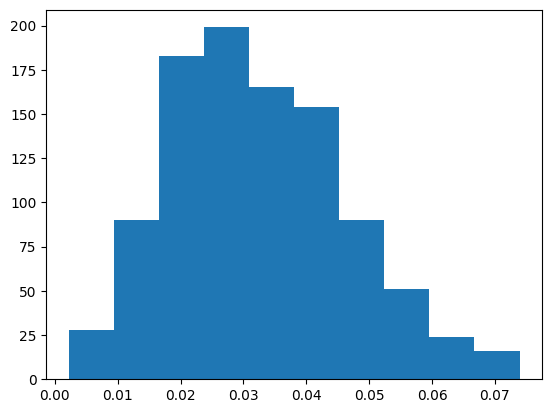

In [16]:
n, k, h, t, d, own, target = load_input('in/0003.txt')

score = 1
for i, (c2,m2,y2) in enumerate(target):
    # print(f'i: {i}', end='')
    errors = []
    for j, (c1,m1,y1) in enumerate(own):
        e = dist((c1,m1,y1), (c2,m2,y2))
        errors.append(e)
        # print(f', k{j} e: {e}', end='')
    score += min(errors)
    # print('')
score *= 10000
score = round(score)
print(f'1つのみscore: {score:,}')


primes = [2, 3, 5]
score = 1
errors = []

for (c,m,y) in tqdm(target):
    # print(f'target: {(c,m,y)}')
    opt_i1 = 0
    opt_i2 = 0
    opt_p = 0
    opt_i = 0
    opt_e = dist((c,m,y), own[0])
    opt_s = opt_e*10000
    for i1 in range(k):
        (c1, m1, y1) = own[i1]
        e = dist((c,m,y), (c1,m1,y1))  # 1つだけ
        s = e*10000
        if opt_s > s:
            # print(f'update {opt_e} => {e}, i1: {i1}, cmy: {(cc,mm,yy)}')
            opt_i1 = i1
            opt_e = e
            opt_s = s
        for i2 in range(k):
            (c2, m2, y2) = own[i2]
            cc = (c1 + c2) / 2
            mm = (m1 + m2) / 2
            yy = (y1 + y2) / 2
            e = dist((c,m,y), (cc,mm,yy))
            s = e*10000+d
            if opt_s > s:
                # print(f'update {opt_e} => {e}, i1: {i1}, i2: {i2}, cmy: {(cc,mm,yy)}')
                opt_i1 = i1
                opt_i2 = i2
                opt_p = 1
                opt_i = 1
                opt_e = e
                opt_s = s
            for p in primes:
                for i in range(1, p):
                    cc = (c1*i + c2*p) / (i+p)
                    mm = (m1*i + m2*p) / (i+p)
                    yy = (y1*i + y2*p) / (i+p)
                    e = dist((c,m,y), (cc,mm,yy))
                    s = e*10000+d
                    if opt_s > s:
                        # print(f'update {opt_e} => {e}, i1: {i1}, i2: {i2}, p: {p}, i: {i}, cmy: {(cc,mm,yy)}')
                        opt_i1 = i1
                        opt_i2 = i2
                        opt_p = 1
                        opt_i = 1
                        opt_e = e
                        opt_s = s
    score += opt_s
    errors.append(opt_e)

print(f'2つ使うscore: {round(score):,}')

plt.hist(errors)
plt.show()

# 重回帰分析

In [17]:
import numpy as np
from sklearn.linear_model import LinearRegression

n, k, h, t, d, own, target = load_input('in/0000.txt')

x = np.array(own).T
y = np.array(target[0])
model = LinearRegression()
model.fit(x, y)
model.coef_

K=4, T=60887, D=3822


array([ 0.14541518,  0.21917037,  0.19615178, -0.0310514 ])

# 絵の具と目標の色の類似度

In [18]:
for a in own:
    b = target[0]
    
    # 内積の計算
    dot_product = np.dot(a, b)

    # ベクトルの大きさを計算
    magnitude_a = np.linalg.norm(a)
    magnitude_b = np.linalg.norm(b)

    # cos値を計算
    cos_theta = dot_product / (magnitude_a * magnitude_b)
    
    print(cos_theta)

0.8249284880174943
0.8416843182016024
0.9105117996763439
0.9625120160935234


## 全色混ぜると

In [19]:
c = 0
m = 0
y = 0

for (c1, m1, y1) in own:
    print(dist((c1, m1, y1), target[0]))
    
    c += c1
    m += m1
    y += y1

c /= len(own)
m /= len(own)
y /= len(own)
print('平均:', dist((c, m, y), target[0]))

0.5202222973883377
0.41548109908875513
0.34330383161275674
0.395481931572101
平均: 0.08387502526080101


In [20]:
score = 1

# 全色混ぜる
for (c1, m1, y1) in own:
    print(dist((c1, m1, y1), target[0]))
    
    c += c1
    m += m1
    y += y1
c /= len(own)
m /= len(own)
y /= len(own)

errors = []
for i, (c2,m2,y2) in enumerate(target):
    e = dist((c,m,y), (c2,m2,y2))
    score += e
    errors.append(e)
score *= 10000
score = round(score)
print(f'score: {score:,}')

0.5202222973883377
0.41548109908875513
0.34330383161275674
0.395481931572101
score: 2,409,778


(array([ 81., 123., 139., 141., 184., 177.,  97.,  39.,  14.,   5.]),
 array([0.07830924, 0.11916828, 0.16002732, 0.20088636, 0.24174541,
        0.28260445, 0.32346349, 0.36432254, 0.40518158, 0.44604062,
        0.48689967]),
 <BarContainer object of 10 artists>)

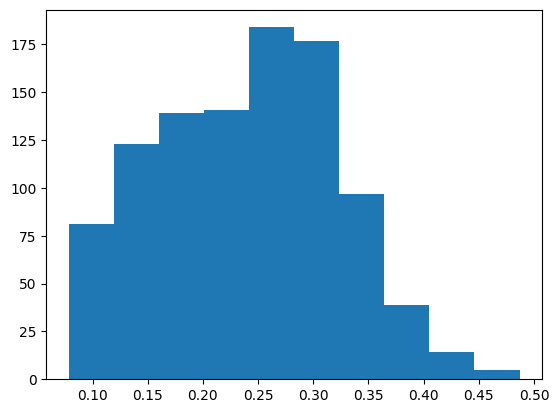

In [21]:
plt.hist(errors)

# ベース色考察(最適解を探す)

In [22]:
n, k, h, t, d, own, target = load_input('in/0000.txt')

def search_color(b):
    trial_cnt = 2
    cnt = 0
    opt_trial = [0, 0, 0, 0]
    opt_score = 1_000_000_000
    opt_color = [0, 0, 0]
    for c1 in range(trial_cnt):
        for c2 in range(trial_cnt):
            for c3 in range(trial_cnt):
                for c4 in range(trial_cnt):
                    trial = [c1, c2, c3, c4]
                    cnt += 1
                    color = mixing_color(trial)
                    # score = 10000*dist(color, target[0]) + d*(sum(trial)-1)
                    score = 10000*dist(color, b)
                    if score < opt_score:
                        # print(f'trial cnt: {cnt}, trial: {trial}, color: {color}, e: {dist(color, target[0])}, score: {round(score)}')
                        opt_score = score
                        opt_trial = trial
                        opt_color = color
    print(f'target: {b}, color: {color}, opt score: {opt_score}, trial: {opt_trial}, cnt: {cnt}')
    return opt_score

search_color(target[0])

K=4, T=60887, D=3822
target: (0.44983, 0.33494, 0.51708), color: (0.4035175, 0.2656975, 0.5073), opt score: 77.44771713155188, trial: [1, 1, 0, 1], cnt: 16


77.44771713155188

In [23]:
def search_one_color(b):
    opt_k = 0
    opt_e = 100
    for k, a in enumerate(own):
        e = dist(a, b)
        if e < opt_e:
            opt_e = e
            opt_k = k
    print(f'target: {b}, color: {own[k]}, opt e: {opt_e*10000}')
    return opt_e*10000

search_one_color(target[0])

target: (0.44983, 0.33494, 0.51708), color: (0.65334, 0.67404, 0.51617), opt e: 3433.038316127567


3433.038316127567

In [24]:
one_score = 1
base_score = 1
for (i, b) in enumerate(target):
    one_score += search_one_color(b)
    base_score += search_color(b)
print(f'one_score: {one_score}')
print(f'base_score: {base_score}')

target: (0.44983, 0.33494, 0.51708), color: (0.65334, 0.67404, 0.51617), opt e: 3433.038316127567
target: (0.44983, 0.33494, 0.51708), color: (0.4035175, 0.2656975, 0.5073), opt score: 77.44771713155188, trial: [1, 1, 0, 1], cnt: 16
target: (0.46831, 0.36471, 0.48477), color: (0.65334, 0.67404, 0.51617), opt e: 3618.108757348237
target: (0.46831, 0.36471, 0.48477), color: (0.4035175, 0.2656975, 0.5073), opt score: 270.25161424124735, trial: [0, 0, 1, 1], cnt: 16
target: (0.50643, 0.31952, 0.31758), color: (0.65334, 0.67404, 0.51617), opt e: 2146.863882503965
target: (0.50643, 0.31952, 0.31758), color: (0.4035175, 0.2656975, 0.5073), opt score: 673.5170813638576, trial: [0, 1, 1, 1], cnt: 16
target: (0.34193, 0.20682, 0.60385), color: (0.65334, 0.67404, 0.51617), opt e: 2063.485384004452
target: (0.34193, 0.20682, 0.60385), color: (0.4035175, 0.2656975, 0.5073), opt score: 787.5801095056227, trial: [1, 0, 1, 1], cnt: 16
target: (0.44749, 0.24562, 0.32353), color: (0.65334, 0.67404, 0.51

## 係数による違い確認

In [25]:
trials = [
    [1,0,0,0], [0,1,0,0], [0,0,1,0], [0,0,0,1],
    [1,1,0,0], [1,0,1,0], [1,0,0,1], [0,1,1,0], [0,1,0,1], [0,0,1,1],
    [0,1,1,1], [1,0,1,1], [1,1,0,1], [1,1,1,0],
    [1,1,1,1],
]
b = target[0]
for trial in trials:
    color = mixing_color(trial)
    score = 10000*dist(color, b) + d*(sum(trial)-1)
    score_e = 10000*dist(color, b)
    print(f'trial: {trial}, score: {score}, score_e: {score_e}')

trial: [1, 0, 0, 0], score: 5202.222973883377, score_e: 5202.222973883377
trial: [0, 1, 0, 0], score: 4154.810990887551, score_e: 4154.810990887551
trial: [0, 0, 1, 0], score: 3433.038316127567, score_e: 3433.038316127567
trial: [0, 0, 0, 1], score: 3954.81931572101, score_e: 3954.81931572101
trial: [1, 1, 0, 0], score: 5758.218966181254, score_e: 1936.218966181253
trial: [1, 0, 1, 0], score: 7731.484401746604, score_e: 3909.484401746604
trial: [1, 0, 0, 1], score: 5801.684387093055, score_e: 1979.6843870930547
trial: [0, 1, 1, 0], score: 6702.665734253109, score_e: 2880.665734253109
trial: [0, 1, 0, 1], score: 6530.679603146153, score_e: 2708.679603146152
trial: [0, 0, 1, 1], score: 4142.35652794972, score_e: 320.35652794972003
trial: [0, 1, 1, 1], score: 9068.485560552377, score_e: 1424.4855605523778
trial: [1, 0, 1, 1], score: 9233.336538377642, score_e: 1589.336538377642
trial: [1, 1, 0, 1], score: 7721.447717131552, score_e: 77.44771713155188
trial: [1, 1, 1, 0], score: 10075.5897

score: 7721.447717131552, score_e: 77.44771713155188, trial: [1, 1, 0, 1]
score: 19187.447717131552, score_e: 77.44771713155188, trial: [2, 2, 0, 2]
score: 15440.262476007714, score_e: 152.26247600771427, trial: [1, 1, 1, 2]
score: 4142.35652794972, score_e: 320.35652794972003, trial: [0, 0, 1, 1]
score: 11786.35652794972, score_e: 320.35652794972003, trial: [0, 0, 2, 2]
score: 23402.220924195233, score_e: 470.22092419523443, trial: [2, 2, 1, 2]
score: 19591.240135829645, score_e: 481.24013582964324, trial: [1, 1, 2, 2]
score: 19856.68437385998, score_e: 746.6843738599774, trial: [1, 2, 1, 2]
score: 16041.62363259123, score_e: 753.6236325912305, trial: [2, 1, 0, 2]
score: 19867.780484375256, score_e: 757.7804843752581, trial: [2, 1, 1, 2]


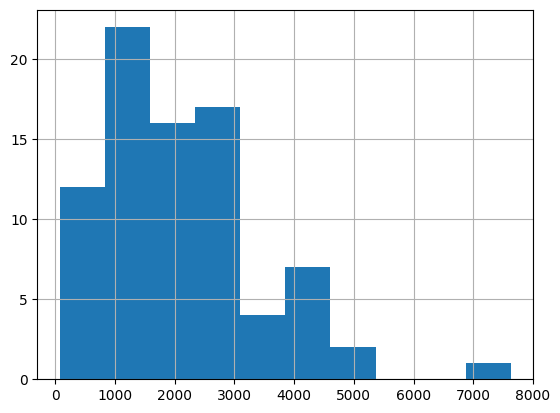

target: (0.44983, 0.33494, 0.51708), color: (0.65334, 0.67404, 0.51617), opt e: 3433.038316127567
10%: 753.6236325912305


count      81.000000
mean     2080.695683
std      1336.901016
min        77.447717
25%      1088.470094
50%      1868.369865
75%      2821.354116
max      7628.260345
dtype: float64

In [26]:
b = target[0]

trial_cnt = 3
cnt = 0
priority_queue = []
for c1 in range(trial_cnt):
    for c2 in range(trial_cnt):
        for c3 in range(trial_cnt):
            for c4 in range(trial_cnt):
                trial = [c1, c2, c3, c4]
                cnt += 1
                color = mixing_color(trial)
                score = 10000*dist(color, target[0]) + d*(sum(trial)-1)
                score_e = 10000*dist(color, b)
                heapq.heappush(priority_queue, (score_e, score, trial))

scores = []
cnt = 0
while priority_queue:
    cnt += 1
    score_e, score, trial = heapq.heappop(priority_queue)
    if cnt <= 10:
        print(f'score: {score}, score_e: {score_e}, trial: {trial}')
    scores.append(score_e)

score_df = pd.Series(scores)
score_df.hist()
plt.show()
search_one_color(b)
print('10%:', score_df.quantile(0.1))
score_df.describe()

## 同じ係数の数

In [27]:
n, k, h, t, d, own, target = load_input('in/0000.txt')

def search_color(b):
    trial_cnt = 3
    cnt = 0
    opt_trial = [0, 0, 0, 0]
    opt_score = 1_000_000_000
    opt_color = [0, 0, 0]
    for c1 in range(trial_cnt):
        for c2 in range(trial_cnt):
            for c3 in range(trial_cnt):
                for c4 in range(trial_cnt):
                    trial = [c1, c2, c3, c4]
                    cnt += 1
                    color = mixing_color(trial)
                    # score = 10000*dist(color, target[0]) + d*(sum(trial)-1)
                    score = 10000*dist(color, b)
                    if score < opt_score:
                        # print(f'trial cnt: {cnt}, trial: {trial}, color: {color}, e: {dist(color, target[0])}, score: {round(score)}')
                        opt_score = score
                        opt_trial = trial
                        opt_color = color
    return opt_trial

trail_dict = {}

for b in target:
    trial = search_color(b)
    trial = str(trial)
    trail_dict[trial] = trail_dict.get(trial, 0) + 1
trail_dict

K=4, T=60887, D=3822


{'[1, 1, 0, 1]': 15,
 '[0, 0, 1, 1]': 24,
 '[0, 2, 1, 1]': 26,
 '[1, 0, 2, 1]': 23,
 '[0, 2, 2, 1]': 36,
 '[2, 0, 1, 2]': 17,
 '[1, 2, 1, 1]': 13,
 '[0, 2, 1, 2]': 17,
 '[1, 2, 1, 0]': 19,
 '[2, 1, 0, 0]': 40,
 '[2, 2, 2, 1]': 21,
 '[2, 0, 1, 1]': 32,
 '[1, 1, 0, 2]': 41,
 '[1, 2, 0, 2]': 13,
 '[0, 1, 2, 1]': 10,
 '[2, 0, 1, 0]': 21,
 '[2, 2, 1, 0]': 24,
 '[1, 1, 2, 0]': 18,
 '[1, 0, 2, 2]': 10,
 '[1, 2, 1, 2]': 14,
 '[0, 0, 1, 2]': 40,
 '[1, 1, 2, 2]': 9,
 '[1, 1, 1, 0]': 10,
 '[1, 2, 0, 0]': 29,
 '[1, 0, 0, 2]': 12,
 '[1, 1, 1, 1]': 15,
 '[2, 1, 0, 1]': 7,
 '[0, 1, 1, 0]': 5,
 '[2, 1, 2, 1]': 29,
 '[0, 2, 1, 0]': 26,
 '[1, 1, 0, 0]': 22,
 '[2, 1, 0, 2]': 18,
 '[2, 1, 2, 0]': 20,
 '[0, 0, 0, 1]': 4,
 '[2, 1, 1, 2]': 14,
 '[1, 2, 2, 1]': 40,
 '[2, 1, 1, 0]': 19,
 '[1, 2, 2, 2]': 19,
 '[2, 0, 2, 1]': 21,
 '[1, 0, 1, 2]': 24,
 '[2, 1, 2, 2]': 9,
 '[2, 1, 1, 1]': 7,
 '[0, 0, 1, 0]': 4,
 '[0, 1, 0, 0]': 5,
 '[1, 2, 0, 1]': 6,
 '[0, 1, 1, 1]': 13,
 '[2, 2, 0, 1]': 4,
 '[2, 0, 0, 1]': 7,
 '[

## seed=0, target=0の最適解は？

In [28]:
n, k, h, t, d, own, target = load_input('in/0001.txt')

a = target[0]

opt_e = 1000000000
opt_comb = []

# 各絵の具を使う使わないで全探索
key = 2
for i in range(1, key**k):
    comb = []
    while i > 0:
        cnt = i%key
        comb.append(cnt)
        i //= key
    color = [0, 0, 0]
    cnt = 0
    for (j, ci) in enumerate(comb):
        cnt += 1
        color[0] += own[j][0]*ci
        color[1] += own[j][1]*ci
        color[2] += own[j][2]*ci
    color[0] /= cnt
    color[1] /= cnt
    color[2] /= cnt
    e = dist(color, a)
    if e < opt_e:
        opt_e = e
        opt_comb = comb
        print(f'update 絵の具パターン{opt_comb}, e={opt_e}')

# 2つの絵の具を使う
primes = [2, 3, 5]
for i1 in range(k):
    (c1, m1, y1) = own[i1]
    for i2 in range(k):
        # 半分ずつ
        (c2, m2, y2) = own[i2]
        cc = (c1 + c2) / 2
        mm = (m1 + m2) / 2
        yy = (y1 + y2) / 2
        e = dist(a, (cc,mm,yy))
        if opt_e > e:
            opt_e = e
            opt_comb = [i1, i2]
            print(f'update 2つ半分{opt_comb}, e={opt_e}')
        # 割合
        for p in primes:
            for i in range(1, p):
                cc = (c1*i + c2*p) / (i+p)
                mm = (m1*i + m2*p) / (i+p)
                yy = (y1*i + y2*p) / (i+p)
                e = dist(a, (cc,mm,yy))
                if opt_e > e:
                    opt_e = e
                    opt_comb = [i1, i2, i, p]
                    print(f'update 2つの割合 絵の具{i1}:絵の具{i2}={i}:{p}, e={opt_e}')

K=9, T=23052, D=13
update 絵の具パターン[1], e=0.27555550185035316
update 絵の具パターン[1, 1], e=0.15187054602522512
update 絵の具パターン[1, 1, 1], e=0.08818126381997982
update 絵の具パターン[1, 1, 1, 1, 1, 1, 1, 1], e=0.04137043887246061
update 2つの割合 絵の具7:絵の具8=2:3, e=0.040928725267225255


In [29]:
a = target[0]
color = own[0]

def mixing_color(color1, color2, p):
    # color1 を p, color2 を 1-p の割合で混ぜる
    color = []
    for i in range(3):
        color.append(color1[i]*p + color2[i]*(1-p))
    return color

opt_e = dist(a, color)
opt_ps = [1]
opt_color = color

for i in range(1, k):
    add_color = own[i]
    # 2分探索で追加の色の割合を決める
    # 初期化
    e1 = opt_e
    e2 = dist(a, add_color)
    p1 = 1
    p2 = 0
    opt_p = p1
    if e1 > e2:
        opt_e = e2
        opt_p = p2
    print(f'{i} start: e1:{e1}, e2:{e2}')
    for j in range(5):
        m_p = (p1 + p2) / 2
        next_color = mixing_color(color, add_color, m_p)
        next_e = dist(a, next_color)
        if opt_e > next_e:
            opt_e = next_e
            opt_color = next_color
            opt_p = m_p
        print(f'{i} {j}回目: e1:{e1}, e2:{e2}, opt_e: {opt_e}, opt_p: {opt_p}')
        if e1 > e2:
            e1 = next_e
            p1 = m_p
        else:
            e2 = next_e
            p2 = m_p
    opt_ps.append(opt_p)
opt_ps

1 start: e1:0.27555550185035316, e2:0.47298836116758736
1 0回目: e1:0.27555550185035316, e2:0.47298836116758736, opt_e: 0.15187054602522512, opt_p: 0.5
1 1回目: e1:0.27555550185035316, e2:0.15187054602522512, opt_e: 0.13344591156157612, opt_p: 0.75
1 2回目: e1:0.13344591156157612, e2:0.15187054602522512, opt_e: 0.1118648858696285, opt_p: 0.625
1 3回目: e1:0.13344591156157612, e2:0.1118648858696285, opt_e: 0.1118648858696285, opt_p: 0.625
1 4回目: e1:0.1148048819362934, e2:0.1118648858696285, opt_e: 0.1111386590355784, opt_p: 0.65625
2 start: e1:0.1111386590355784, e2:0.34489363432803455
2 0回目: e1:0.1111386590355784, e2:0.34489363432803455, opt_e: 0.1111386590355784, opt_p: 1
2 1回目: e1:0.1111386590355784, e2:0.18477994547569282, opt_e: 0.1111386590355784, opt_p: 1
2 2回目: e1:0.1111386590355784, e2:0.19802230123776463, opt_e: 0.1111386590355784, opt_p: 1
2 3回目: e1:0.1111386590355784, e2:0.2315507142817206, opt_e: 0.1111386590355784, opt_p: 1
2 4回目: e1:0.1111386590355784, e2:0.25255545720661776, opt

[1, 0.65625, 1, 1, 1, 1, 1, 1, 1]

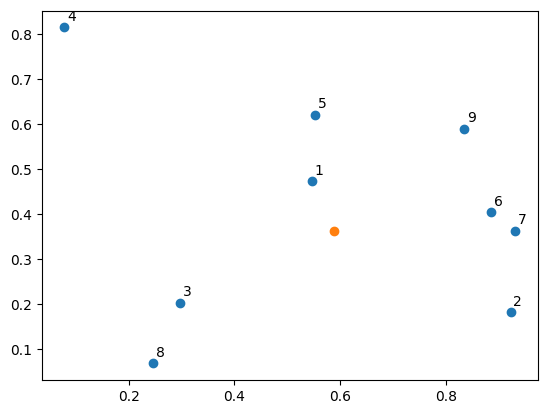

In [30]:
x = []
y = []
for (c, m, _) in own:
    x.append(c)
    y.append(m)
(x2, y2, _) = target[0]

plt.scatter(x, y)
plt.scatter([x2], [y2])
for i, (xi, yi) in enumerate(zip(x, y), start=1):  # 1から始まるラベル
    plt.annotate(f'{i}', (xi, yi), textcoords="offset points", xytext=(5, 5), ha='center')
plt.show()

In [34]:
import numpy as np
from scipy.optimize import minimize, nnls

def optimize(own, a):
    # 各ベクトルを列として行列Aを作成（ここでAの形状は (3, K)）
    A = np.array(own).T

    # 目標とする3次元のベクトルV
    V = np.array(a)

    # 最小化する目的関数 (二乗和誤差)
    def objective(c):
        return np.linalg.norm(A.dot(c) - V)**2

    # 等式制約: 係数の和が 1 になるようにする
    cons = {'type': 'eq', 'fun': lambda c: np.sum(c) - 1}

    # 係数はすべて 0 以上であるという非負の制約
    bounds = [(0, None) for _ in range(A.shape[1])]

    # 非負最小二乗法により、係数を求める
    coefficients, residual = nnls(A, V)

    # 初期値として、均等に割り当てた値を使用（和が1となるようにする）
    initial_guess = np.ones(A.shape[1]) / A.shape[1]

    result = minimize(objective, initial_guess, method='SLSQP', bounds=bounds, constraints=cons)

    if result.success:
        c_optimal = result.x
        # print("求めた係数:", c_optimal)
        # print("残差:", np.linalg.norm(A.dot(c_optimal) - V))
    else:
        print("最適化に失敗しました:", result.message)

    (c, m, y) = (0, 0, 0)
    for i in range(k):
        (ci, mi, yi) = own[i]
        pi = c_optimal[i]
        c += ci*pi
        m += mi*pi
        y += yi*pi
    e = dist(target[0], (c, m, y))
    # print(f'{cnt}, e:', e)
    return e, c_optimal

e, c_optimal = optimize(own, target[0])
e, c_optimal

(0.00039150674396547366,
 array([0.10770413, 0.1297794 , 0.13639446, 0.07149973, 0.08964835,
        0.1060752 , 0.11552168, 0.15533059, 0.08804645]))

In [35]:
for cnt in range(1, 100):
    coef = list(map(int, c_optimal*cnt))

    (c, m, y) = (0, 0, 0)
    for i in range(k):
        (ci, mi, yi) = own[i]
        pi = coef[i]
        c += ci*pi
        m += mi*pi
        y += yi*pi
    all_cnt = sum(coef)
    if all_cnt == 0:
        continue
    c /= all_cnt
    m /= all_cnt
    y /= all_cnt
    print(f'e: {dist(target[0], (c, m, y))}, coef: {coef}')

e: 0.5490565775946956, coef: [0, 0, 0, 0, 0, 0, 0, 1, 0]
e: 0.23514638679389102, coef: [0, 1, 1, 0, 0, 0, 0, 1, 0]
e: 0.1704379885214854, coef: [0, 1, 1, 0, 0, 0, 1, 1, 0]
e: 0.10059275969361697, coef: [1, 1, 1, 0, 0, 1, 1, 1, 0]
e: 0.10059275969361697, coef: [1, 1, 1, 0, 0, 1, 1, 1, 0]
e: 0.06472275795170504, coef: [1, 1, 1, 0, 1, 1, 1, 1, 1]
e: 0.05699165357995653, coef: [1, 1, 1, 0, 1, 1, 1, 2, 1]
e: 0.03891874687088473, coef: [1, 1, 1, 1, 1, 1, 1, 2, 1]
e: 0.057159994173235217, coef: [1, 1, 2, 1, 1, 1, 1, 2, 1]
e: 0.03609996414279532, coef: [1, 2, 2, 1, 1, 1, 1, 2, 1]
e: 0.03609996414279532, coef: [1, 2, 2, 1, 1, 1, 1, 2, 1]
e: 0.015541617824904387, coef: [1, 2, 2, 1, 1, 1, 2, 2, 1]
e: 0.020583035960065003, coef: [2, 2, 2, 1, 1, 2, 2, 2, 1]
e: 0.02855666483748807, coef: [2, 2, 2, 1, 1, 2, 2, 3, 1]
e: 0.02855666483748807, coef: [2, 2, 2, 1, 1, 2, 2, 3, 1]
e: 0.03708368530657323, coef: [2, 2, 3, 1, 1, 2, 2, 3, 1]
e: 0.00774394782897185, coef: [2, 2, 3, 1, 2, 2, 2, 3, 2]
e: 0.01747988

In [37]:
a = target[2]

def mixing_color(color1, color2, p):
    # color1 を p, color2 を 1-p の割合で混ぜる
    color = []
    for i in range(3):
        color.append(color1[i]*p + color2[i]*(1-p))
    return color

last_opt_e = 10000000
opt_k1 = 0
opt_k2 = 0
last_opt_p = 1

for k1 in range(k):
    for k2 in range(k1+1,k):
        color1 = own[k1]
        color2 = own[k2]
        # 2分探索で2つの絵の具の割合を決める
        # 初期化
        e1 = dist(a, color1)
        e2 = dist(a, color2)
        p1 = 1
        p2 = 0
        if e1 < e2:
            opt_e = e1
            opt_p = p1
        else:
            opt_e = e2
            opt_p = p2
        for j in range(5):
            m_p = (p1 + p2) / 2
            next_color = mixing_color(color1, color2, m_p)
            next_e = dist(a, next_color)
            if opt_e > next_e:
                opt_e = next_e
                opt_color = next_color
                opt_p = m_p
            if e1 > e2:
                e1 = next_e
                p1 = m_p
            else:
                e2 = next_e
                p2 = m_p
        print(f'k1: {k1}, k2: {k2}, opt_e: {opt_e}, opt_p: {opt_p}')
        if last_opt_e > opt_e:
            last_opt_e = opt_e
            opt_k1 = k1
            opt_k2 = k2
            last_opt_p = opt_p
print(f'last k1: {opt_k1}, k2: {opt_k2}, opt_e: {last_opt_e}, opt_p: {last_opt_p}')

k1: 0, k2: 1, opt_e: 0.23478214761117175, opt_p: 0.78125
k1: 0, k2: 2, opt_e: 0.03838174552888073, opt_p: 0.4375
k1: 0, k2: 3, opt_e: 0.2294084500447905, opt_p: 0.78125
k1: 0, k2: 4, opt_e: 0.2577615558661135, opt_p: 0.59375
k1: 0, k2: 5, opt_e: 0.24430450645739357, opt_p: 0.78125
k1: 0, k2: 6, opt_e: 0.27880873031524683, opt_p: 1
k1: 0, k2: 7, opt_e: 0.2375759926338867, opt_p: 0.71875
k1: 0, k2: 8, opt_e: 0.26905735343764015, opt_p: 0.84375
k1: 1, k2: 2, opt_e: 0.21465353452569788, opt_p: 0.125
k1: 1, k2: 3, opt_e: 0.3464428128524943, opt_p: 0.53125
k1: 1, k2: 4, opt_e: 0.28182723144089655, opt_p: 0.1875
k1: 1, k2: 5, opt_e: 0.5703805472452416, opt_p: 0.0625
k1: 1, k2: 6, opt_e: 0.5043428302306657, opt_p: 0.4375
k1: 1, k2: 7, opt_e: 0.25123976459251035, opt_p: 0.375
k1: 1, k2: 8, opt_e: 0.5014138720897373, opt_p: 0.21875
k1: 2, k2: 3, opt_e: 0.22356699826120005, opt_p: 0.90625
k1: 2, k2: 4, opt_e: 0.08653767238490342, opt_p: 0.5625
k1: 2, k2: 5, opt_e: 0.19689401383382316, opt_p: 0.81

# 3つの絵の具を使う最適解

In [38]:
n, k, h, t, d, own, target = load_input('in/0001.txt')

t = target[0]
v1 = own[0]
v2 = own[1]
v3 = own[2]

def dot(v1, v2):
    ret = 0
    for i in range(3):
        ret += v1[i]*v2[i]
    return ret

def subtract(v1, v2):
    ret = []
    for i in range(3):
        ret.append(v1[i]-v2[i])
    return ret

def mixing_3color(v1, v2, v3, a, b):
    v = []
    for i in range(3):
        v.append(v1[i]*(1-a-b)+v2[i]*a+v3[i]*b)
    return v

def opt_3color(t, v1, v2, v3):
    t_v1 = subtract(t, v1)
    v3_v1 = subtract(v3, v1)
    v2_v1 = subtract(v2, v1)

    b = (dot(t_v1, v3_v1)*dot(v2_v1, v2_v1) - dot(t_v1, v2_v1)*dot(v3_v1, v2_v1)) / (dot(v3_v1, v3_v1)*dot(v2_v1, v2_v1) - dot(v3_v1, v2_v1)*dot(v3_v1, v2_v1))
    a = (dot(t_v1, v2_v1) - b*dot(v3_v1, v2_v1)) / dot(v2_v1, v2_v1)

    color = mixing_3color(v1, v2, v3, a, b)
    return color, a, b

color, a, b = opt_3color(t, v1, v2, v3)
dist(t, color)

K=9, T=23052, D=13


0.04118341997505518

In [57]:
t = target[0]

def opt_3color_all_patterns(t):
    opt_params = [0, 0, 0, 0, 0, 0]
    opt_e = 100000
    for k1 in range(k):
        for k2 in range(k1+1, k):
            for k3 in range(k2+1, k):
                v1 = own[k1]
                v2 = own[k2]
                v3 = own[k3]
                color, a, b = opt_3color(t, v1, v2, v3)
                e = dist(t, color)
                if opt_e > e:
                    opt_e = e
                    opt_color = color
                    # print(f'opt_e: {opt_e}, k1: {k1}, k2: {k2}, k3: {k3}, a: {a} , b: {b}')
                    opt_params = [k1, k2, k3, a, b, opt_e, opt_color]
    return opt_params

k1, k2, k3, a, b, opt_e, opt_color = opt_3color_all_patterns(t)
print(f'opt_e: {opt_e}, k1: {k1}, k2: {k2}, k3: {k3}, a: {a} , b: {b}')

opt_e: 0.0018315560640184724, k1: 0, k2: 1, k3: 3, a: 0.3250446641533814 , b: 0.33268654340876


In [58]:
n, k, h, t, d, own, target = load_input('in/0001.txt')

sum_opt_e = 0
for i in range(h):
    opt_e = 100000
    t = target[i]

    k1, k2, k3, a, b, opt_e, opt_color = opt_3color_all_patterns(t)
    sum_opt_e += opt_e
    # print(f'i: {i}, opt_e: {opt_e}')
sum_opt_e, sum_opt_e/h

K=9, T=23052, D=13


(2.7938313075965913, 0.002793831307596591)

In [59]:
n, k, h, t, d, own, target = load_input('in/0000.txt')

sum_opt_e = 0
for i in range(h):
    opt_e = 100000
    t = target[i]

    k1, k2, k3, a, b, opt_e, opt_color = opt_3color_all_patterns(t)
    sum_opt_e += opt_e
    # print(f'i: {i}, opt_e: {opt_e}')
sum_opt_e, sum_opt_e/h

K=4, T=60887, D=3822


(3.725171964429995, 0.003725171964429995)

## 係数の差分の影響

In [90]:
n, k, h, t, d, own, target = load_input('in/0000.txt')
t = target[1]

k1, k2, k3, a, b, opt_e, opt_color = opt_3color_all_patterns(t)
print(f'opt_e: {opt_e}, k1: {k1}, k2: {k2}, k3: {k3}, a: {a} , b: {b}, opt_color: {opt_color}')

def merge_color(k1, k2, k3, coef):
    c, m, y = [0, 0, 0]
    for i, k in enumerate([k1, k2, k3]):
        (ci, mi, yi) = own[k]
        c += ci*coef[i]
        m += mi*coef[i]
        y += yi*coef[i]
    sum_coef = sum(coef)
    c /= sum_coef
    m /= sum_coef
    y /= sum_coef
    return (c, m, y)

print('\n◆理想')
coef = [1-a-b, a, b]
print(f'coef: {coef}, sum_coef: {sum(coef)}')
color = merge_color(k1, k2, k3, coef)
print(f'e: {dist(t, color)}, merge_color: {color}')

print('\n◆10倍切り上げ')
times = 10
coef = [math.ceil((1-a-b)*times), math.ceil(a*times), math.ceil(b*times)]
print(f'coef: {coef}, sum_coef: {sum(coef)}, 正規化coef: {[v/sum(coef) for v in coef]}')
color = merge_color(k1, k2, k3, coef)
print(f'e: {dist(t, color)}, merge_color: {color}')

print('\n◆19倍切り上げ')
times = 19
coef = [math.ceil((1-a-b)*times), math.ceil(a*times), math.ceil(b*times)]
print(f'coef: {coef}, sum_coef: {sum(coef)}, 正規化coef: {[v/sum(coef) for v in coef]}')
color = merge_color(k1, k2, k3, coef)
print(f'e: {dist(t, color)}, merge_color: {color}')

K=4, T=60887, D=3822
opt_e: 0.006083694136747158, k1: 1, k2: 2, k3: 3, a: 0.4516446062504761 , b: 0.4865434428717382, opt_color: [0.4635119368490136, 0.3678982121744203, 0.482814181123029]

◆理想
coef: [0.06181195087778574, 0.4516446062504761, 0.4865434428717382], sum_coef: 1.0
e: 0.006083694136747158, merge_color: (0.4635119368490136, 0.3678982121744203, 0.482814181123029)

◆10倍切り上げ
coef: [1, 5, 5], sum_coef: 11, 正規化coef: [0.09090909090909091, 0.45454545454545453, 0.45454545454545453]
e: 0.02014870528826572, merge_color: (0.4585863636363637, 0.35338363636363634, 0.4712372727272727)

◆19倍切り上げ
coef: [2, 9, 10], sum_coef: 21, 正規化coef: [0.09523809523809523, 0.42857142857142855, 0.47619047619047616]
e: 0.015006567345401326, merge_color: (0.4684852380952381, 0.3675428571428571, 0.4700342857142856)


# Tの分布

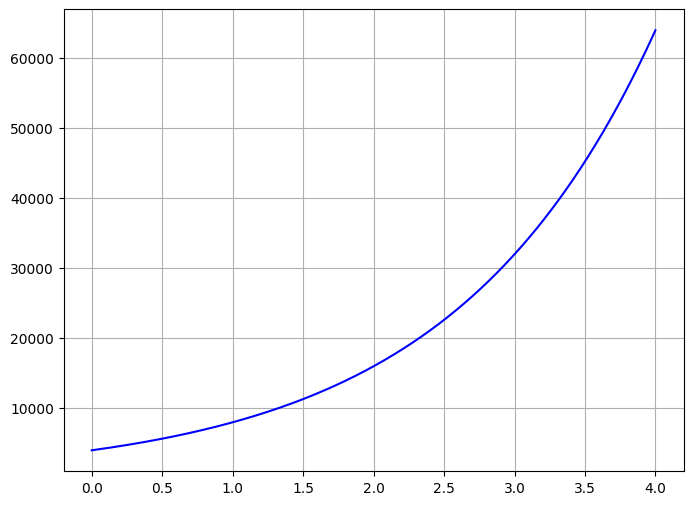

In [42]:
# 0から1までの等間隔な値を生成
samples = np.linspace(0, 4, 1000)

# 対応する値を計算
values = 4000*(2**samples)

# グラフをプロット
plt.figure(figsize=(8, 6))
plt.plot(samples, values, color="blue")
plt.grid()
plt.show()

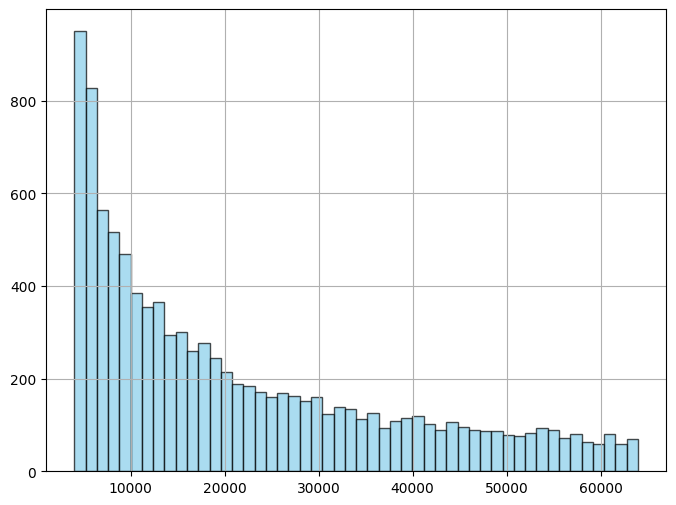

count    10000.000000
mean     21463.306097
std      16269.133464
min       4000.516191
25%       7947.472302
50%      15893.239080
75%      31623.271679
max      63977.441428
dtype: float64

In [43]:
# サンプル数
num_samples = 10000

# モンテカルロでランダム値を生成 (1から4の範囲でランダムサンプリング)
random_samples = np.random.uniform(0, 4, num_samples)

# 対応する値を計算：10^samples
values = 4000*(2**random_samples)

# ヒストグラムをプロット
plt.figure(figsize=(8, 6))
plt.hist(values, bins=50, color='skyblue', alpha=0.7, edgecolor='black')
plt.grid()
plt.show()

pd.Series(values).describe()